#### Group members:
#### Hugo Toth


# <center> **App10: Blood Pressure Estimation Using Photoplethysmogram**

## Background
Blood pressure (BP) is an important cardiovascular parameter indicating the pressure of blood on blood vessel wall per unit area. BP is the main driving force that promotes the circulation of blood in the body. 

The most common non-invasive method to measure BP is to use a cuff-based BP monitor to detect Korotkoff sounds caused by turbulent blood flow. Pulse transit time – extracted from electrocardiogram (ECG) and photoplethysmogram (PPG) – can be also used to estimate systolic and diastolic BP values. 

However, these methods cannot be used to monitor BP continuously in everyday settings due to the limitations in their setups and data collection. Recent studies proposed to use machine-learning techniques to extract BP using only PPG signals.

## Objective
The objective of this project is to extract systolic and diastolic BP from PPG signals. Using machine-learning algorithms, we will train two regressors to estimate the BP parameters.

Multi-parameter Intelligent Monitoring in Intensive Care (MIMIC) II online waveform database provided by PhysioNet organization is used in this project. The data were collected from different hospitals between 2001 to 2008. The waveform signals include PPG signals from fingertip and arterial BP detected by invasive sensors with unit of mmHg. All signals are sampled at 125Hz.

## 0. Library Imports

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, periodogram, find_peaks, welch
from scipy.stats import skew, kurtosis, entropy as shannon_entropy
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
from lifelines.utils import concordance_index

# 1. Data Loading and Exploring

### Structure of the Data

- The project includes the PPG of 29599 records (i.e., 23675 records for training and 5924 records for test). Each record (i.e., file) consists of 10 seconds of PPG signals sampled at 125 Hz. The dataset includes separate "Train" and "Test" folders.
- The folders contain 2 subfolders as "PPG" and "BP". The "PPG" subfolder includes the PPG records. Each record is saved as a CSV file, including one column corresponding to the amplitude value of PPG signal.
- The filename includes the index number of PPG segment. For example, the first 10-second PPG segment is named as "PPG_0.csv".
- The "BP" subfolder includes the BP records of each 10-second PPG segment. The CSV file contains three columns, including the systolic blood pressure (SBP), diastolic blood pressure (DBP), and the corresponding PPG segment name (e.g., PPG_0.csv).

First, we define the paths. This code is running from the same directory that contains the "data" folder:

In [2]:
# Base directories
data_dir = "data"

train_ppg_dir = os.path.join(data_dir, "Train", "PPG")
train_bp_file = os.path.join(data_dir, "Train", "BP", "BP_train.csv")

test_ppg_dir = os.path.join(data_dir, "Test", "PPG")
test_bp_file = os.path.join(data_dir, "Test", "BP", "BP_test.csv")

We use a function to load both the training and testing datasets.

In [3]:
def load_dataset(ppg_dir, bp_csv_path):
    """
    Loads PPG data and corresponding SBP/DBP from directory and CSV metadata.

    Returns:
        X: list of numpy arrays (PPG signals)
        y: numpy array of shape (N, 2) with SBP and DBP
        filenames: list of filenames
    """
    # Load the BP CSV
    bp_df = pd.read_csv(bp_csv_path)
    
    # Storage
    X = []
    y = []
    filenames = []
    
    for _, row in bp_df.iterrows():
        filename = row['ppg_file']
        sbp = row['sbp']
        dbp = row['dbp']
        file_path = os.path.join(ppg_dir, filename)
        
        if os.path.exists(file_path):
            ppg_values = pd.read_csv(file_path, header=0).squeeze().values  # shape: (1250,)
            X.append(ppg_values)
            y.append([sbp, dbp])
            filenames.append(filename)
        else:
            print(f"Missing file.")
    
    return np.array(X), np.array(y), filenames

In [4]:
# Load training data
X_train, y_train, train_filenames = load_dataset(train_ppg_dir, train_bp_file)

# Load testing data
X_test, y_test, test_filenames = load_dataset(test_ppg_dir, test_bp_file)

print(f"Training samples loaded: {len(X_train)}")
print(f"Testing samples loaded: {len(X_test)}")

Training samples loaded: 23675
Testing samples loaded: 5924


Now we can explore the data, printing the shape of the arrays and some sample signal values. Each sample should have 1250 PPG values.

In [5]:
# Check overall shapes
print("Data Shapes\n")
print("X_train shape:", np.array(X_train).shape)  
print("y_train shape:", y_train.shape)            
print("X_test shape:", np.array(X_test).shape)    
print("y_test shape:", y_test.shape)              

# Check a few samples
print("\nSample values")
for i in range(3):
    print(f"\nSample {i+1}:")
    print("Filename:", train_filenames[i])
    print("PPG signal (first 10 values):", X_train[i][:10])
    print("SBP / DBP:", y_train[i])

Data Shapes

X_train shape: (23675, 1250)
y_train shape: (23675, 2)
X_test shape: (5924, 1250)
y_test shape: (5924, 2)

Sample values

Sample 1:
Filename: PPG_0.csv
PPG signal (first 10 values): [1.92766373 2.0742913  2.2111437  2.31964809 2.40664712 2.49071359
 2.56500489 2.62658847 2.67546432 2.71163245]
SBP / DBP: [150.54715112  61.77210145]

Sample 2:
Filename: PPG_1.csv
PPG signal (first 10 values): [2.15347019 2.0684262  1.98338221 1.90127077 1.8230694  1.7487781
 1.67839687 1.61192571 1.55522972 1.50244379]
SBP / DBP: [163.14305643  69.58519673]

Sample 3:
Filename: PPG_2.csv
PPG signal (first 10 values): [1.94428152 1.90518084 1.87390029 1.8455523  1.81524927 1.78396872
 1.75268817 1.72238514 1.69305963 1.66373412]
SBP / DBP: [146.19040409  69.81776265]


###  Plotting PPG Signal vs Time
By plotting some samples of the PPG, the aim is to visually verify the quality of the signals and see the general trends (periodicity, noise). This helps to understand the shape of the waveforms before any filtering or feature extraction.

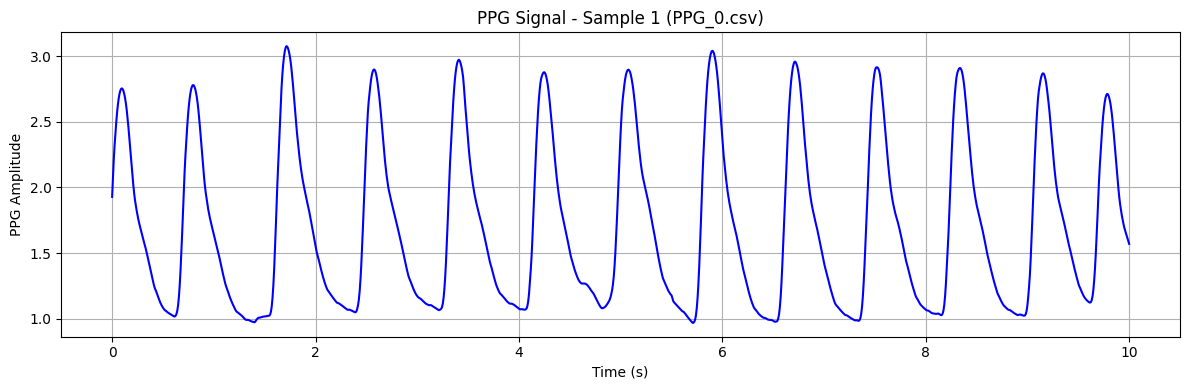

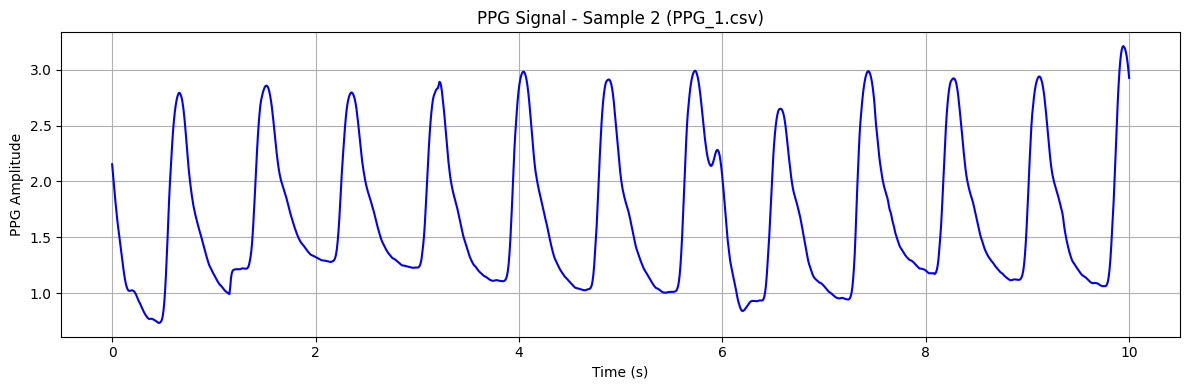

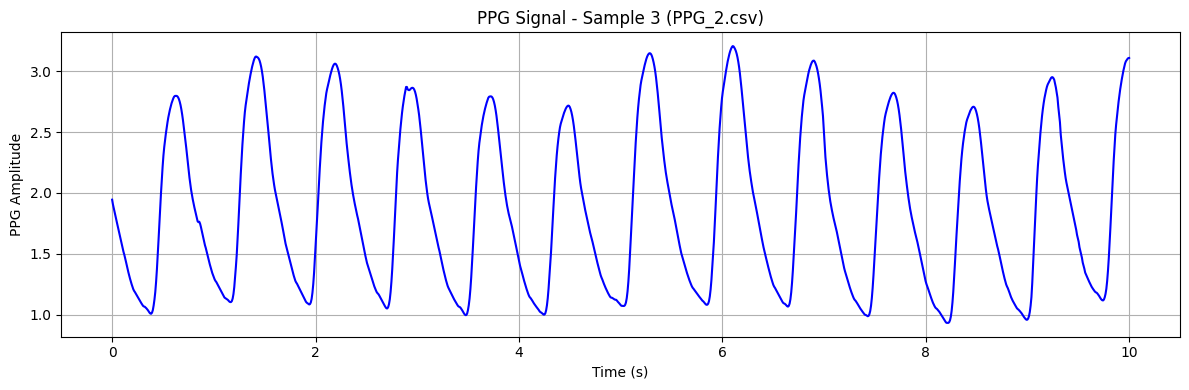

In [6]:
# Sampling info
fs = 125  # Hz
duration = 10  # seconds
time_axis = np.linspace(0, duration, fs * duration)  # 0 to 10s, 1250 points

for i in range(3):
    plt.figure(figsize=(12, 4))
    plt.plot(time_axis, X_train[i], color='blue')
    plt.title(f"PPG Signal - Sample {i+1} ({train_filenames[i]})")
    plt.xlabel("Time (s)")
    plt.ylabel("PPG Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 2. Preprocessing - Filtering

PPG signals are often noisy due to motion artifacts, power-line interferences, and low-amplitude trends or premature ventricular contractions. We want to isolate the cardiac components (i.e., the heartbeats), which fall in a fairly narrow frequency band. Heart rates for most adults usually range from 0.7 to 3 Hz (40–180 bpm). So, we should design a bandpass filter that surrounds this area.

We will use a Butterworth filter of order 4 with cutoff frequencies equal to (dominant_freq – 0.4) and (dominant_freq + 0.4) and filter the original PPG signal. The dominant frequencies are obtained from the power spectrum. 

We will implement this for just one sample first, plot both signals and verify the output.

In [7]:
def get_dominant_freq(signal, fs):
    freqs, power = periodogram(signal, fs)
    dominant_freq = freqs[np.argmax(power[1:]) + 1]  # ignore DC component
    return dominant_freq

def bandpass_filter(signal, fs, lowcut, highcut, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    return filtered

Dominant frequency: 1.20 Hz
Filtering between 0.80 Hz and 1.60 Hz


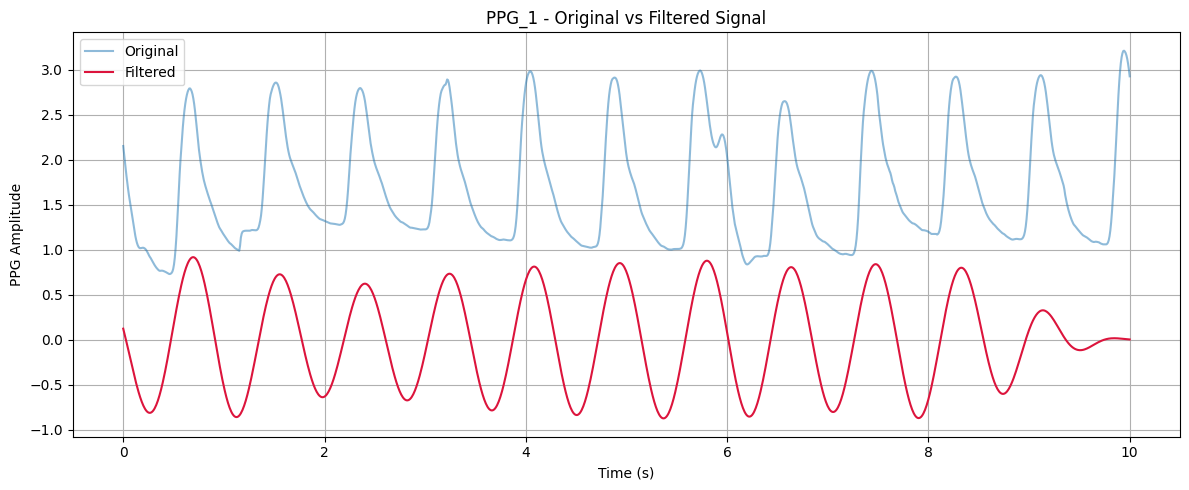

In [8]:
# Parameters
fs = 125  # sampling rate
signal_1 = X_train[1]  # PPG_1
dominant_freq_1 = get_dominant_freq(signal_1, fs)
lowcut_1 = max(dominant_freq_1 - 0.4, 0.01)  # avoid zero
highcut_1 = dominant_freq_1 + 0.4

print(f"Dominant frequency: {dominant_freq_1:.2f} Hz")
print(f"Filtering between {lowcut_1:.2f} Hz and {highcut_1:.2f} Hz")

# Filter the signal
filtered_signal_1 = bandpass_filter(signal_1, fs, lowcut_1, highcut_1)

# Time axis
time_axis = np.linspace(0, 10, len(signal_1))

# Plot original vs filtered
plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal_1, label='Original', alpha=0.5)
plt.plot(time_axis, filtered_signal_1, label='Filtered', color='crimson')
plt.title("PPG_1 - Original vs Filtered Signal")
plt.xlabel("Time (s)")
plt.ylabel("PPG Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The original PPG signal had a characteristic sharp systolic peak and a more gradual diastolic slope. The applied bandpass filter cleaned up the signal, extracting the periodic “heartbeat rhythm” component. Isolating the the dominant frequency creates a smooth, sinusoid-like signal, without noise and baseline wander.

Now we can loop through all PPG signals in X_train and X_test. For each, we will estimate the dominant frequency, design a Butterworth bandpass filter around that frequency and store both the raw and filtered signal.

In [9]:
# Process all signals (TRAIN)
X_train_filtered = []
for signal in X_train:
    dominant_freq = get_dominant_freq(signal, fs)
    lowcut = max(dominant_freq - 0.4, 0.01)  # avoid 0 Hz
    highcut = dominant_freq + 0.4
    filtered = bandpass_filter(signal, fs, lowcut, highcut)
    X_train_filtered.append(filtered)

# Convert list to array
X_train_filtered = np.array(X_train_filtered)

# Process all signals (TEST)
X_test_filtered = []
for signal in X_test:
    dominant_freq = get_dominant_freq(signal, fs)
    lowcut = max(dominant_freq - 0.4, 0.01)
    highcut = dominant_freq + 0.4
    filtered = bandpass_filter(signal, fs, lowcut, highcut)
    X_test_filtered.append(filtered)

X_test_filtered = np.array(X_test_filtered)

In [10]:
# Confirm shapes
print("Filtered signal shapes:")
print("X_train_filtered:", X_train_filtered.shape)
print("X_test_filtered:", X_test_filtered.shape)

Filtered signal shapes:
X_train_filtered: (23675, 1250)
X_test_filtered: (5924, 1250)


# 3. Feature Extraction

While the filtering enhances the heartbeat-related waveform (which is where a lot of useful features for SBP/DBP estimation live) and makes it easier to detect peaks and valleys, measure interbeat intervals and extract waveform shape features, it's not the whole story. It doesn’t preserve the exact original shape of the PPG, which contains high-frequency content useful for SBP/DBP models.

This is why we will use a hybrid approach. The extract_features() function is designed to compute a comprehensive set of physiological and morphological features from both the raw and filtered PPG (photoplethysmogram) signals. These features capture aspects of cardiovascular dynamics, signal shape, variability, and frequency content, all of which may be relevant for estimating blood pressure accurately.

### Interbeat Interval (IBI)
- The average time between successive systolic peaks (heartbeats), measured in seconds.
- IBI is a direct indicator of heart rate. Variations in IBI are commonly used in HRV (heart rate variability) analysis, which has a known relationship with blood pressure regulation.
- Filtering helps ensure cleaner peak detection by removing noise and baseline wander.

### Time Interval Between Systolic and Diastolic Peaks
- Average time between the systolic peak (highest point) and the following diastolic trough (lowest point) within each cardiac cycle.
- Reflects vascular compliance and pulse transit time, both of which are related to arterial stiffness and blood pressure.
- Cleaner signal helps isolate peaks and troughs more reliably.

### Amplitude Ratio (Systolic/Diastolic)
- The ratio between the systolic peak amplitude and the following diastolic minimum.
- Represents changes in blood volume dynamics. Abnormal ratios can reflect poor vascular tone or peripheral resistance.

### Systolic Amplitude
- The average height of systolic peaks.
- Strongly associated with stroke volume and vascular distensibility. Some studies suggest it's promising for estimating systolic blood pressure.
- The absolute amplitude is preserved best in the unfiltered signal.

### Pulse Width
- The average Full Width at Half Maximum (FWHM) of the pulse wave - how long the pulse stays above half of its peak amplitude.
- Correlates with systemic vascular resistance. Wider pulses often suggest slower blood flow.

### Pulse Area (AUC)
- Area under the curve of the PPG waveform.
- Reflects the total blood volume changes during each pulse. Alterations can indicate perfusion anomalies.

### Peak-to-Peak Interval
- Average time between consecutive systolic peaks.
- Closely related to IBI and used to estimate heart rate, but we extract it also from the raw signal for balance.

### Skewness
- Measures the asymmetry of the waveform.
- The PPG waveform is typically right-skewed. Changes in skewness might indicate waveform distortions due to vascular conditions.

### Kurtosis
- Measures the "tailedness" of the waveform distribution.
- Abnormal values might reflect atypical pulse shapes or sensor movement.

###  Shannon Entropy (of signal amplitude)
- Quantifies the complexity or disorder of the signal.
- Higher entropy may indicate irregular, noisy signals; lower entropy could indicate a stable cardiovascular state.

### SDNN
- SDNN is standard deviation of the time interval between successive normal heart beats.
- A common HRV measure; reflects long-term variability of heart rate.
- Reduced HRV is often linked to cardiovascular dysfunction, including hypertension.

### RMSSD
- RMSSD is the root mean square of successive RR interval differences.
- HRV metric capturing short-term variability in beat-to-beat intervals.

### Total Power (frequency domain)
- Sum of power spectral density across all frequencies (from Welch’s method).
- Reflects the total variability present in the signal. Can relate to autonomic function or signal strength.

### Spectral Entropy
- Shannon entropy computed over the power spectrum.
- Measures irregularity in the frequency components. Can help distinguish structured signals (e.g., clean heartbeats) from noisy ones.

In [11]:
def extract_features(ppg_raw, ppg_filtered, fs=125):
    features = []

    # ---------- From FILTERED ----------
    # 1. Peak detection
    peaks, _ = find_peaks(ppg_filtered, distance=fs*0.4)  # At least 0.4s apart

    # 2. Interbeat Interval (IBI)
    if len(peaks) > 1:
        ibis = np.diff(peaks) / fs  # in seconds
        mean_ibi = np.mean(ibis)
    else:
        mean_ibi = 0
        ibis = []
    features.append(mean_ibi)

    # 3. Time interval between systolic and diastolic peaks + amplitude ratio (estimate using local min after each peak)
    time_deltas = []
    amp_ratios = []
    for peak in peaks:
        search_range = ppg_filtered[peak:peak + int(0.4 * fs)]  # 400 ms after the peak
        if len(search_range) < 2:
            continue
        diastolic_rel_idx = np.argmin(search_range)
        diastolic_idx = peak + diastolic_rel_idx
        delta_t = (diastolic_idx - peak) / fs
        amp_ratio = ppg_filtered[peak] / (ppg_filtered[diastolic_idx] + 1e-6)  # avoid divide by zero

        time_deltas.append(delta_t)
        amp_ratios.append(amp_ratio)

    features.append(np.mean(time_deltas) if time_deltas else 0)
    features.append(np.mean(amp_ratios) if amp_ratios else 0)

    # ---------- From RAW ----------
    # 4. Systolic Amplitude
    raw_peaks, _ = find_peaks(ppg_raw, distance=fs*0.4)
    systolic_amplitudes = ppg_raw[raw_peaks] if len(raw_peaks) else [0]
    features.append(np.mean(systolic_amplitudes))

    # 5. Pulse Width (FWHM)
    pulse_widths = []
    for peak in raw_peaks:
        peak_val = ppg_raw[peak]
        half_max = peak_val / 2
        # Search to the left
        left = peak
        while left > 0 and ppg_raw[left] > half_max:
            left -= 1
        # Search to the right
        right = peak
        while right < len(ppg_raw) - 1 and ppg_raw[right] > half_max:
            right += 1
        width = (right - left) / fs
        pulse_widths.append(width)
    features.append(np.mean(pulse_widths) if pulse_widths else 0)

    # 6. Pulse Area (area under the curve)
    pulse_area = np.trapz(ppg_raw)
    features.append(pulse_area)

    # 7. Peak-to-Peak Interval
    if len(raw_peaks) > 1:
        peak_to_peak = np.diff(raw_peaks) / fs
        features.append(np.mean(peak_to_peak))
    else:
        features.append(0)

    # 8. Skewness
    features.append(skew(ppg_raw))

    # 9. Kurtosis
    features.append(kurtosis(ppg_raw))

    # 10. Shannon Entropy
    hist, _ = np.histogram(ppg_raw, bins=50, density=True)
    features.append(shannon_entropy(hist + 1e-6))

    # ---------- Heart Rate Variability ----------
    if len(ibis) > 1:
        sdnn = np.std(ibis)
        rmssd = np.sqrt(np.mean(np.diff(ibis)**2))
    else:
        sdnn = 0
        rmssd = 0
    features.extend([sdnn, rmssd])

    # ---------- Frequency Domain ----------
    # 13. Total Power
    freqs, power = welch(ppg_raw, fs=fs, nperseg=fs*2)
    total_power = np.sum(power)

    # 14. Spectral Entropy
    spectral_entropy = shannon_entropy(power + 1e-6)
    features.extend([total_power, spectral_entropy])

    return features

In [12]:
# Extract the features from the train and test datasets
X_train_features = [extract_features(raw, filt) for raw, filt in zip(X_train, X_train_filtered)]
X_test_features = [extract_features(raw, filt) for raw, filt in zip(X_test, X_test_filtered)]

# Convert to NumPy arrays
X_train_features = np.array(X_train_features)
X_test_features = np.array(X_test_features)

print("Feature shape (train):", X_train_features.shape)
print("Feature shape (test):", X_test_features.shape)

Feature shape (train): (23675, 14)
Feature shape (test): (5924, 14)


For better visualization, we will convert the feature arrays into pandas DataFrames. We can label each feature with its name, which will allow to easily explore, plot, sort, and describe the features. Thus, we will be able to decide if any additional processing is necessary.

In [13]:
# Feature labels
feature_names = [
    "Mean_IBI",
    "SysDia_TimeDelta",
    "SysDia_AmplitudeRatio",
    "Systolic_Amplitude",
    "Pulse_Width",
    "Pulse_Area",
    "PeakToPeak_Interval",
    "Skewness",
    "Kurtosis",
    "ShannonEntropy",
    "SDNN",
    "RMSSD",
    "Total_Power",
    "SpectralEntropy"
]


# Convert to DataFrames
X_train_df = pd.DataFrame(X_train_features, columns=feature_names)
X_test_df = pd.DataFrame(X_test_features, columns=feature_names)

In [14]:
# Data info
print(X_train_df.info())

# Peek into the first few rows
print("\n--- First few rows of training features ---")
print(X_train_df.head())

# Quick stats
print("\n--- Summary statistics ---")
print(X_train_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23675 entries, 0 to 23674
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Mean_IBI               23675 non-null  float64
 1   SysDia_TimeDelta       23675 non-null  float64
 2   SysDia_AmplitudeRatio  23675 non-null  float64
 3   Systolic_Amplitude     23675 non-null  float64
 4   Pulse_Width            23675 non-null  float64
 5   Pulse_Area             23675 non-null  float64
 6   PeakToPeak_Interval    23675 non-null  float64
 7   Skewness               23675 non-null  float64
 8   Kurtosis               23675 non-null  float64
 9   ShannonEntropy         23675 non-null  float64
 10  SDNN                   23675 non-null  float64
 11  RMSSD                  23675 non-null  float64
 12  Total_Power            23675 non-null  float64
 13  SpectralEntropy        23675 non-null  float64
dtypes: float64(14)
memory usage: 2.5 MB
None

--- First fe

# 4. Plots for Feature Exploration

Since we're dealing with physiological signals and trying to estimate blood pressure (a continuous outcome), here are some insightful plots that can help us:

## Histograms
- Show how each feature is distributed. Good for spotting outliers, or need for scaling.

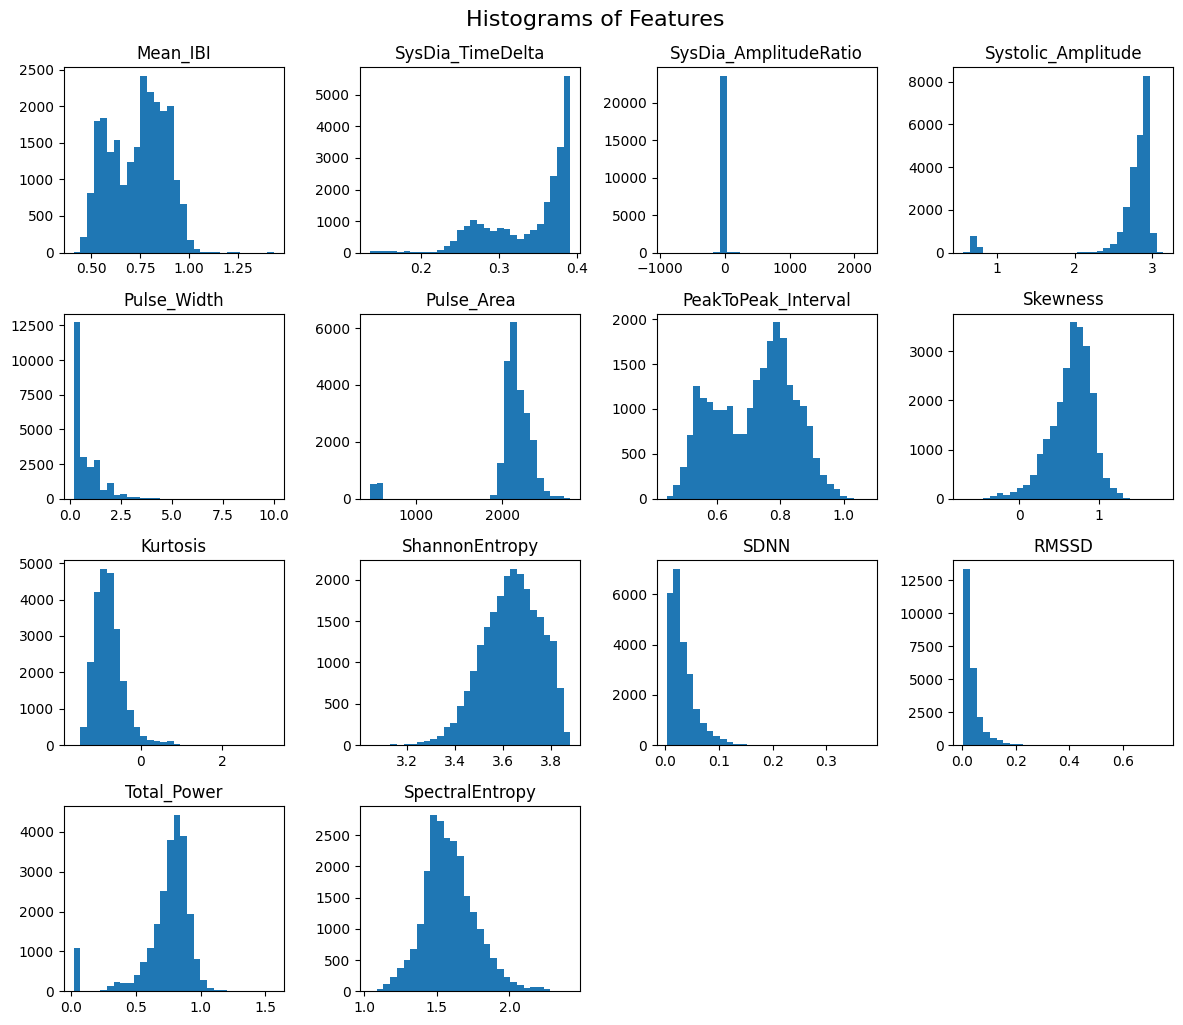

In [15]:
X_train_df.hist(figsize=(12, 10), bins=30, grid=False)
plt.tight_layout()
plt.suptitle("Histograms of Features", fontsize=16, y=1.02)
plt.show()

## Boxplot
- Great for visualizing the range and identifying outliers for each feature.

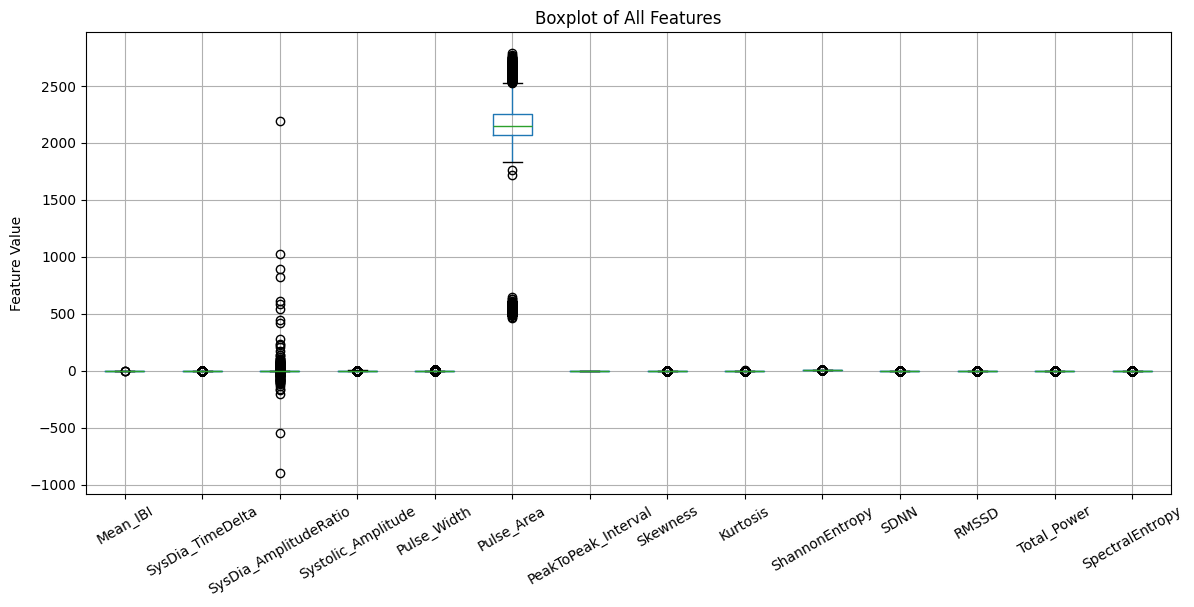

In [16]:
plt.figure(figsize=(14, 6))
X_train_df.boxplot(rot=45)
plt.title("Boxplot of All Features")
plt.ylabel("Feature Value")
plt.xticks(rotation=30)
plt.show()

## Correlation Heatmap
- For checking if any features are redundant (i.e., highly correlated).

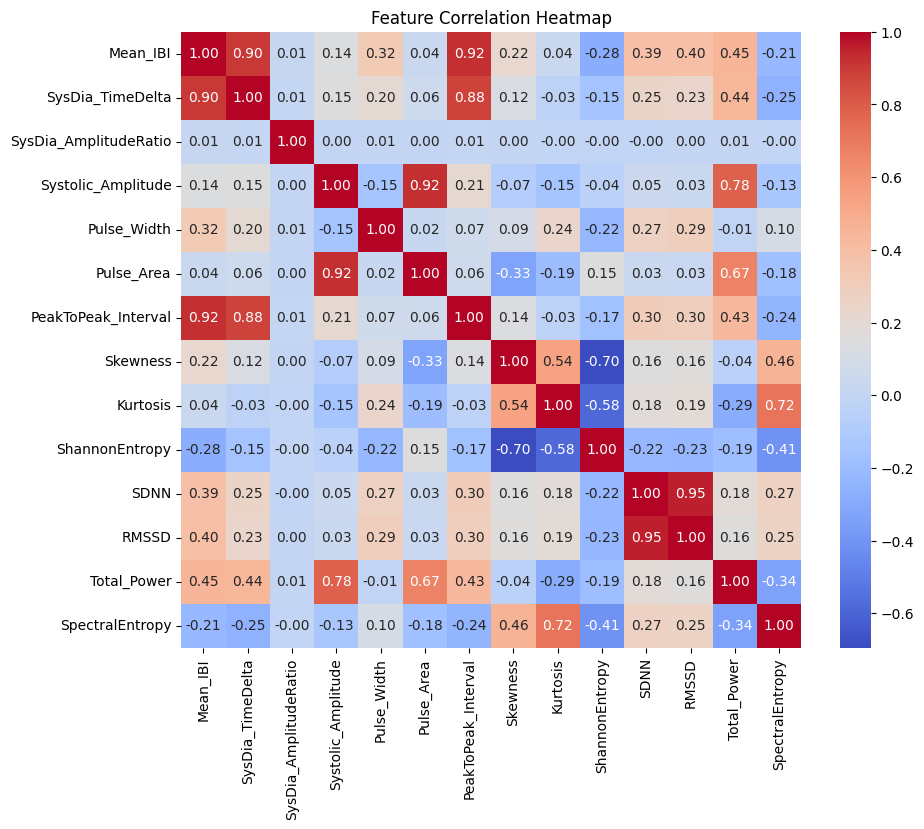

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

From the plots, we can see that some features are highly correlated, like 'Mean_IBI' and 'PeakToPeak_Interval' (both are based on interbeat intervals) or 'SDNN' and 'RMSSD' (both are HRV measures). This is expected, so we can keep them and test model performance.

'SysDia_AmplitudeRatio' has an unexpected distribution (histogram) with many outliers (boxplot) with extreme values. It also shows absolutely no correlation with any of the other features, which suggests something may be wrong. For these reasons, we decide to drop this feature entirely so that it doesn't skew the models.

In [18]:
# Drop the 'SysDia_AmplitudeRatio' feature from the DataFrames
X_train_df = X_train_df.drop(columns=["SysDia_AmplitudeRatio"])
X_test_df = X_test_df.drop(columns=["SysDia_AmplitudeRatio"])

# Confirm it is gone
print("Remaining features:", list(X_train_df.columns))

Remaining features: ['Mean_IBI', 'SysDia_TimeDelta', 'Systolic_Amplitude', 'Pulse_Width', 'Pulse_Area', 'PeakToPeak_Interval', 'Skewness', 'Kurtosis', 'ShannonEntropy', 'SDNN', 'RMSSD', 'Total_Power', 'SpectralEntropy']


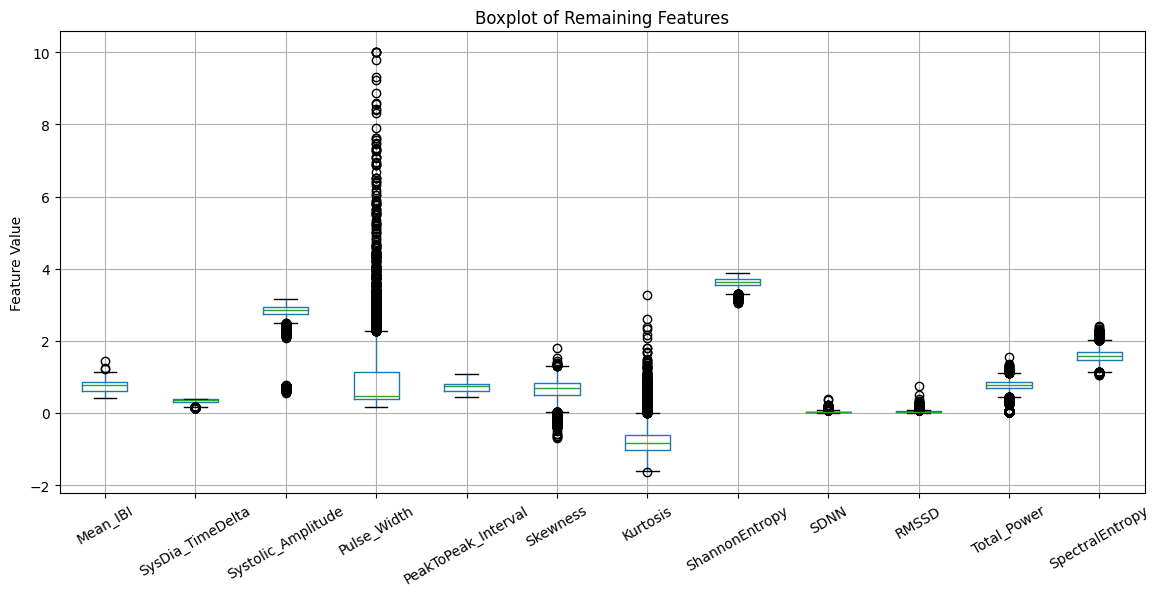

In [19]:
plt.figure(figsize=(14, 6))
X_train_df.drop(columns=["Pulse_Area"]).boxplot(rot=45)
plt.title("Boxplot of Remaining Features")
plt.ylabel("Feature Value")
plt.xticks(rotation=30)
plt.show()

# 5. Feature Standardization

We will use StandardScaler for normalization, which transforms each feature to have a mean of 0 and a standard deviation of 1. This ensures features are on the same scale and contribute equally to the ML models, helping with convergence and performance (they train better and faster). Standardization is especially important when the features have different value ranges, like 'Pulse_Area' in our case (which has much larger numerical values).

In [20]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
scaler.fit(X_train_df)
X_train_scaled = scaler.transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)

# Convert back to DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_df.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_df.columns)

# Check result
print("Training data mean (after scaling):")
print(X_train_scaled_df.mean().round(2))
print("\nTraining data std (after scaling):")
print(X_train_scaled_df.std().round(2))

Training data mean (after scaling):
Mean_IBI              -0.0
SysDia_TimeDelta       0.0
Systolic_Amplitude    -0.0
Pulse_Width           -0.0
Pulse_Area            -0.0
PeakToPeak_Interval   -0.0
Skewness               0.0
Kurtosis               0.0
ShannonEntropy        -0.0
SDNN                  -0.0
RMSSD                 -0.0
Total_Power           -0.0
SpectralEntropy       -0.0
dtype: float64

Training data std (after scaling):
Mean_IBI               1.0
SysDia_TimeDelta       1.0
Systolic_Amplitude     1.0
Pulse_Width            1.0
Pulse_Area             1.0
PeakToPeak_Interval    1.0
Skewness               1.0
Kurtosis               1.0
ShannonEntropy         1.0
SDNN                   1.0
RMSSD                  1.0
Total_Power            1.0
SpectralEntropy        1.0
dtype: float64


In [21]:
X_train_scaled_df.head()

,Mean_IBI,SysDia_TimeDelta,Systolic_Amplitude,Pulse_Width,Pulse_Area,PeakToPeak_Interval,Skewness,Kurtosis,ShannonEntropy,SDNN,RMSSD,Total_Power,SpectralEntropy
0,0.519246,0.531296,0.354300,-0.554350,0.039339,0.704031,-0.000459,-0.483264,0.291414,0.619014,0.297513,0.384856,-0.253188
1,0.661803,0.582730,0.071388,0.454768,-0.071826,0.747938,0.260159,0.019863,0.206173,0.316414,-0.053066,0.192476,-0.260556
2,0.214199,0.448210,0.449259,-0.443519,0.626198,0.505454,-1.058842,-1.350617,1.297160,0.379074,-0.024823,1.029098,-1.728092
3,-1.355054,-1.294613,-4.406919,-0.582616,-4.201088,-1.384757,-1.041037,-0.899464,1.678003,-0.906056,-0.807766,-3.465599,0.195343
4,-0.797222,-0.789916,-4.352440,-0.653174,-4.312923,-0.691569,0.695258,0.347137,0.529915,-0.170362,-0.434420,-3.444924,0.135559


# 6. Model Training and Evaluation

We will implement and evaluate two regression models for the task of estimating systolic and diastolic blood pressure based on the previously extracted features from the photoplethysmography (PPG) signals:
- A Random Forest Regressor.
- A Multi-Layer Perceptron (MLP) Regressor.

Both models will be wrapped in a MultiOutputRegressor to enable simultaneous prediction of both systolic and diastolic pressure.

## Random Forest
Random Forest is an ensemble-based machine learning algorithm that constructs multiple decision trees and aggregates their predictions. It is particularly effective for structured data (like our extracted feature vectors) due to a series of strengths:
- Non-linear modeling: Capable of capturing complex, non-linear relationships between features and blood pressure.
- Robust to noise and overfitting, due to averaging across many trees.
- Feature interpretability: Offers insights into feature importance, which is useful in physiological data analysis.

Given the complexity and variability of physiological signals, Random Forests are well-suited to generalize without requiring extensive hyperparameter tuning or assumptions about the underlying data.

In [22]:
# Train Random Forest Regressor
rf = MultiOutputRegressor(RandomForestRegressor(n_estimators=200, random_state=2003))
rf.fit(X_train_scaled_df, y_train)
rf_pred = rf.predict(X_test_scaled_df)

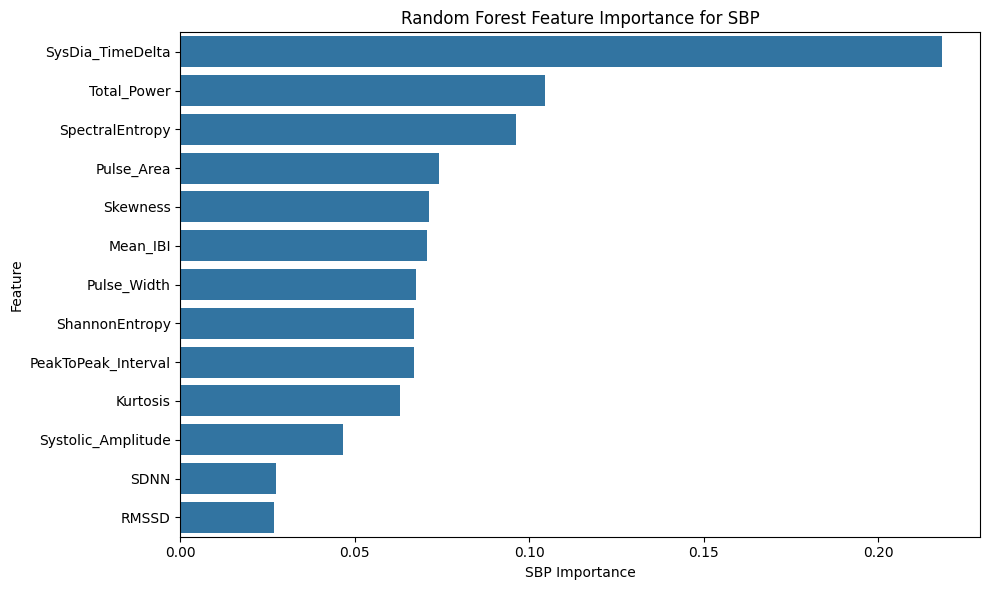

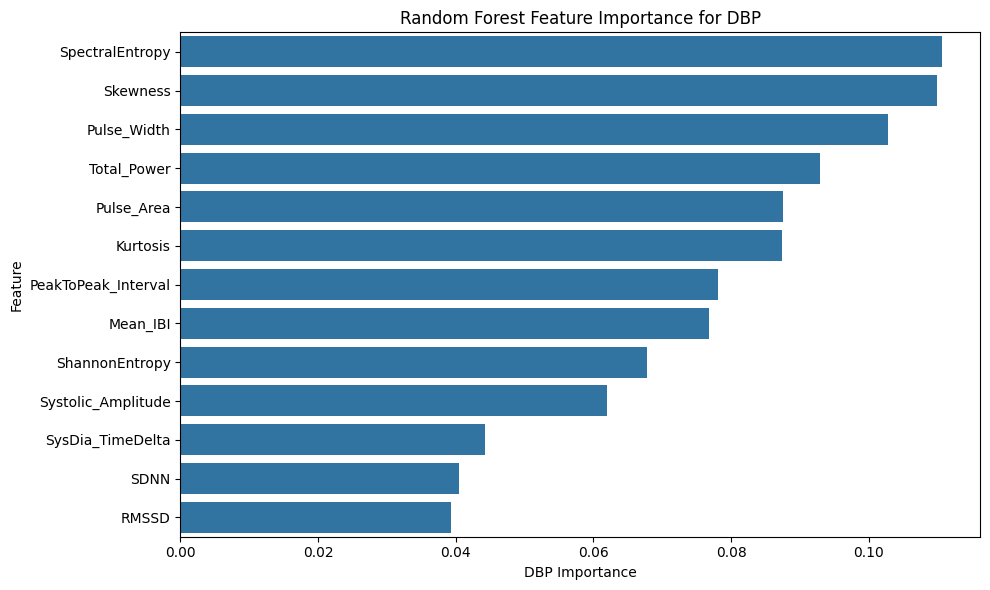

In [23]:
# Get feature names
feature_names = X_train_scaled_df.columns

# Get the underlying Random Forest regressors
rf_sbp = rf.estimators_[0]  # Regressor for SBP
rf_dbp = rf.estimators_[1]  # Regressor for DBP

# Get importances
importances_sbp = rf_sbp.feature_importances_
importances_dbp = rf_dbp.feature_importances_

# Create a DataFrame to hold them
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'SBP Importance': importances_sbp,
    'DBP Importance': importances_dbp
})

# Sort by importance
importance_df = importance_df.sort_values('SBP Importance', ascending=False)

# Plot SBP feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='SBP Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importance for SBP')
plt.tight_layout()
plt.show()

# Plot DBP feature importances
importance_df = importance_df.sort_values('DBP Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='DBP Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importance for DBP')
plt.tight_layout()
plt.show()

## Multi-Layer Perceptron (MLP)
The MLP is a type of feedforward artificial neural network capable of modeling non-linear patterns through its multi-layer structure. With proper regularization and early stopping, MLPs can learn complex feature combinations relevant to cardiovascular dynamics and generalize well to unseen data. Their architecture is easily adjustable to more layers or units for deeper learning.

Given the multi-dimensional and interdependent nature of the PPG-derived features, a neural network can discover patterns that may be difficult to explicitly model using traditional methods. This makes it a good choice for biometric regression tasks like blood pressure estimation.

In [24]:
# Train MLP Regressor
mlp = MultiOutputRegressor(MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=2004,
    early_stopping=True
))
mlp.fit(X_train_scaled_df, y_train)
mlp_pred = mlp.predict(X_test_scaled_df)

To evaluate the performance of the machine learning models on the blood pressure prediction task, we use two metrics:

### Mean Absolute Error (MAE)
MAE measures the average magnitude of errors between predicted and true blood pressure values. It is expressed in mmHg (making it directly interpretable), robust to outliers and commonly used in clinical benchmarks.

### Concordance Index (C-index)
The C-index measures the agreement between the orderings of predicted and true values. It captures the model’s ability to rank individuals correctly by blood pressure.

We calculate both the MAE and the C-index separately for:
  - **SBP (Systolic Blood Pressure)**
  - **DBP (Diastolic Blood Pressure)**

In [25]:
# Evaluation function
def evaluate_model(name, y_true, y_pred):
    sbp_mae = mean_absolute_error(y_true[:, 0], y_pred[:, 0])
    dbp_mae = mean_absolute_error(y_true[:, 1], y_pred[:, 1])
    sbp_cindex = concordance_index(y_true[:, 0], y_pred[:, 0])
    dbp_cindex = concordance_index(y_true[:, 1], y_pred[:, 1])
    
    print(f"\n {name} Evaluation:")
    print(f"SBP MAE: {sbp_mae:.2f} mmHg")
    print(f"DBP MAE: {dbp_mae:.2f} mmHg")
    print(f"SBP Concordance Index: {sbp_cindex:.3f}")
    print(f"DBP Concordance Index: {dbp_cindex:.3f}")

# Evaluate both models
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("MLP Regressor", y_test, mlp_pred)


 Random Forest Evaluation:
SBP MAE: 10.08 mmHg
DBP MAE: 4.88 mmHg
SBP Concordance Index: 0.799
DBP Concordance Index: 0.753

 MLP Regressor Evaluation:
SBP MAE: 12.11 mmHg
DBP MAE: 5.92 mmHg
SBP Concordance Index: 0.760
DBP Concordance Index: 0.702


## Conclusion

The evaluation results show that the **Random Forest Regressor** outperformed the **MLP Regressor** in both accuracy and consistency, achieving lower MAE and higher concordance index for both SBP and DBP. In particular, DBP predictions met clinically acceptable error margins, while SBP estimates showed higher variability, which is expected due to its physiological complexity. Overall, the results demonstrate the effectiveness of machine learning with engineered PPG features for non-invasive blood pressure estimation, with Random Forest proving to be a robust and reliable model for this task.